### Naive Bayes - Beispiel: Movie Reviews

[Video](https://youtu.be/XZLFVL0RKfs)

Der Klassifier soll herausfinden, ob die Kommentare zum Movie eher negativ oder eher positiv sind (Sentiment-Analyse).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer,  TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay 

In [2]:
df = pd.read_csv('moviereviews.csv')

In [3]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [4]:
print(df.iloc[0]['review'])

how do films like mouse hunt get into theatres ? 
isn't there a law or something ? 
this diabolical load of claptrap from steven speilberg's dreamworks studio is hollywood family fare at its deadly worst . 
mouse hunt takes the bare threads of a plot and tries to prop it up with overacting and flat-out stupid slapstick that makes comedies like jingle all the way look decent by comparison . 
writer adam rifkin and director gore verbinski are the names chiefly responsible for this swill . 
the plot , for what its worth , concerns two brothers ( nathan lane and an appalling lee evens ) who inherit a poorly run string factory and a seemingly worthless house from their eccentric father . 
deciding to check out the long-abandoned house , they soon learn that it's worth a fortune and set about selling it in auction to the highest bidder . 
but battling them at every turn is a very smart mouse , happy with his run-down little abode and wanting it to stay that way . 
the story alternates betwee

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2000 non-null   object
 1   review  1965 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [6]:
# check, ob felder nicht belegt sind
df.isnull().sum()

label      0
review    35
dtype: int64

In [7]:
df = df.dropna()
df.isnull().sum()

label     0
review    0
dtype: int64

In [8]:
# check, ob review nur leerer space ist
df['review'].str.isspace().sum()

np.int64(27)

In [9]:
df = df[~df['review'].str.isspace()]
df['review'].str.isspace().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1938 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1938 non-null   object
 1   review  1938 non-null   object
dtypes: object(2)
memory usage: 45.4+ KB


In [11]:
df['label'].value_counts()

label
neg    969
pos    969
Name: count, dtype: int64

In [12]:
print(df.iloc[201]['review'])

look ! the new version of " psycho " came out and the world didn't end ! 
i guess gus van sant really isn't the bringer of the apocalypse ! 
unfortunately , though , that " psycho " didn't end the world as we know is the best thing that can be said for it . 
van sant's controversial " re-telling " of alfred hitchcock's classic 1960 film has polarized filmgoers everywhere ( even before it premiered . ) 
without benefit of an actual viewing , many have said that the film will , at best , suck . 
being an ( almost ) good critic , i waited until i actually saw it to decide that the film , at best , sucked ( and that concludes the use of the word " suck " and , hopefully , the thoughts that i am a brain-dead orangutan . ) 
director gus van sant took the original hitchcock film and refilmed it , shot-for-shot , using the same , exact script ( with a few minor alterations . ) 
the inherent challenge was in making the film suspenseful and scary , even though a large group of the audience will 

In [13]:
X = df['review']
y = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [15]:
X_train.shape

(1550,)

In [24]:
# vectorizer = CountVectorizer(stop_words='english')
vectorizer = CountVectorizer()
# vectorizer = TfidfVectorizer(stop_words='english')
# vectorizer = TfidfVectorizer()
X_train_v = vectorizer.fit_transform(X_train)

In [25]:
X_train_v.shape

(1550, 35380)

In [26]:
vectorizer.get_feature_names_out()[1000:1200]

array(['adultrous', 'adults', 'advance', 'advanced', 'advancement',
       'advances', 'advancing', 'advantage', 'advantaged', 'advantages',
       'advent', 'adventure', 'adventurer', 'adventures', 'adventurous',
       'adversarial', 'adversaries', 'adversary', 'adverse', 'adversely',
       'adversity', 'advertise', 'advertised', 'advertisement',
       'advertisements', 'advertiser', 'advertising', 'advertisment',
       'advice', 'advil', 'advisable', 'advise', 'advised', 'adviser',
       'advisers', 'advises', 'advising', 'advisor', 'advisors',
       'advocate', 'advocated', 'advocates', 'advocating', 'aerial',
       'aerosmith', 'aerospace', 'aesthetic', 'aesthetically',
       'aesthetics', 'afar', 'afer', 'affability', 'affable', 'affair',
       'affairs', 'affay', 'affect', 'affectation', 'affectations',
       'affected', 'affecting', 'affection', 'affectionate',
       'affectionately', 'affections', 'affects', 'afficianados',
       'affiliate', 'affiliated', 'affiliat

In [27]:
model = MultinomialNB()
model.fit(X_train_v,y_train);

In [28]:
bed_wk = pd.DataFrame(model.feature_log_prob_, 
                      index=model.classes_, 
                      columns=vectorizer.get_feature_names_out())
bed_wk.iloc[:, 2000:2020]  

,aristocrats,arizona,arizonians,ark,arkham,arkin,arlene,arli,arlington,arliss,arlo,arm,armada,armageddon,armand,armande,armando,armani,armed,armful
neg,-13.106874,-10.708979,-12.413727,-10.708979,-13.106874,-10.216502,-13.106874,-12.413727,-11.72058,-12.008262,-12.008262,-10.111142,-13.106874,-9.705677,-12.008262,-13.106874,-13.106874,-12.413727,-10.062352,-12.413727
pos,-12.507180,-10.897743,-13.200328,-11.120886,-12.507180,-12.101715,-12.101715,-13.200328,-12.50718,-12.101715,-11.590890,-10.427739,-12.101715,-10.492277,-12.507180,-11.814033,-12.507180,-13.200328,-10.109285,-13.200328


In [29]:
X_test_v = vectorizer.transform(X_test)
y_pred = model.predict(X_test_v)

In [30]:
acc = accuracy_score(y_test, y_pred)
acc

0.8247422680412371

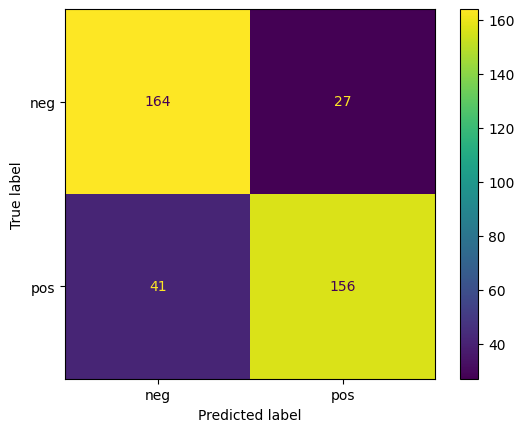

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()


#### Exkurs: TF-IDF


- TF – Term Frequency → wie häufig taucht das Wort in dem Dokument auf.
- IDF – Inverse Document Frequency → wie selten ist das Wort in allen Dokumenten
- Multipliziere beides → Worte die häufig vorkommen und seltener in allen Dokumenten auftauchen, bekommen mehr Gewicht

In [32]:
texte = [
    "I love cats",
    "I love dogs",
    "Dogs and cats are great"
]

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words='english')
# vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(texte)
vectorizer.get_feature_names_out()

array(['cats', 'dogs', 'great', 'love'], dtype=object)

In [34]:
df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df

,cats,dogs,great,love
0,0.707107,0.000000,0.000000,0.707107
1,0.000000,0.707107,0.000000,0.707107
2,0.517856,0.517856,0.680919,0.000000


<img src='tfidf.png' width='700'>

In [35]:
# Berechnung für love in Zeile 1
tf = 1     # Wieviel mal kommt das Wort im Dokument vor
docf = 2   # Wieviel mal kommt das Wort in allen Dokumenten vor
n_docs = 3 # Anzahl Dokumente
idf = math.log((1 + n_docs) / (1 + docf)) + 1.
tfidf = tf*idf
tfidf

1.2876820724517808

In [36]:
# Feature Vektor für Dokument 1 
# dogs erhält denselben tfidf wert
v = (0, tfidf, 0, tfidf)
v

(0, 1.2876820724517808, 0, 1.2876820724517808)

In [37]:
laenge = math.sqrt(tfidf**2 + tfidf**2)   # Normalisierung
tfidf = tfidf/laenge

In [38]:
v = (0, tfidf, 0, tfidf)
v

(0, 0.7071067811865476, 0, 0.7071067811865476)